In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# read the file with the pcp information from GPM and IMN
imn_df = pd.read_csv('./Data/harmonized/unif_IMN.csv')
gpm_df = pd.read_csv('./Data/harmonized/unif_GPM.csv')

In [3]:
def convert_index(df, col_name):
    """
    Assign a specific column as a index
    """
    # convert 'date' column to datetime 
    df.loc[:, col_name] = pd.to_datetime(df[col_name])

    # set the 'date' column as the index
    df.set_index(col_name, inplace=True)
    
    return df

In [4]:
# assigning 'date' as index
imn_df = convert_index(imn_df, 'date')
gpm_df = convert_index(gpm_df, 'date')

In [5]:
temp_resol = {
    '1D': '1 día',
    '7D': '1 semana',
    '1M': '1 mes'
}

In [6]:
imn_tmp = imn_df.fillna(0)

In [7]:
# Define your T_fourier function
def T_fourier(df, col_name, d):
    W = np.hamming(len(df))
    FT = np.fft.fft(W * (df[col_name] - df[col_name].mean()))
    XFT = np.fft.fftfreq(len(FT), d=d)
    return {'XFT': XFT, 'FT': FT}

In [8]:
# Function to find the top 5 highest signals from Fourier Transform 
def find_top_signals(df, d):
    top_signals = []
    
    for station in df.columns:
        result = T_fourier(df, station, d)
        magnitudes = np.abs(result['FT'])
        frequencies = result['XFT']
        
        # Consider only positive frequencies
        positive_frequencies = frequencies[frequencies > 0]
        positive_magnitudes = magnitudes[frequencies > 0]
        
        # Get the top 5 indices of the highest magnitudes
        top_indices = np.argsort(positive_magnitudes)[-5:][::-1]
        
        for i in range(5):
            top_signals.append({
                'station': station,
                'frequency': positive_frequencies[top_indices[i]],
                'magnitude': positive_magnitudes[top_indices[i]]
            })
    
    return top_signals

In [9]:
d = 3600  # for hourly data

# Find top signals for IMN data
top_signals_IMN = find_top_signals(imn_tmp, d)

# Find top signals for GPM data
top_signals_GPM = find_top_signals(gpm_df, d)

In [11]:
top_signals_IMN = pd.DataFrame(top_signals_IMN)
top_signals_GPM = pd.DataFrame(top_signals_GPM)

In [12]:
top_signals_IMN.loc[:, 'period'] = 1/top_signals_IMN['frequency']*(1/86400)
top_signals_GPM.loc[:, 'period'] = 1/top_signals_GPM['frequency']*(1/86400)

In [15]:
TF_1 = T_fourier(imn_tmp, '84141', 3600)
TF_2 = T_fourier(gpm_df, '84141', 3600)

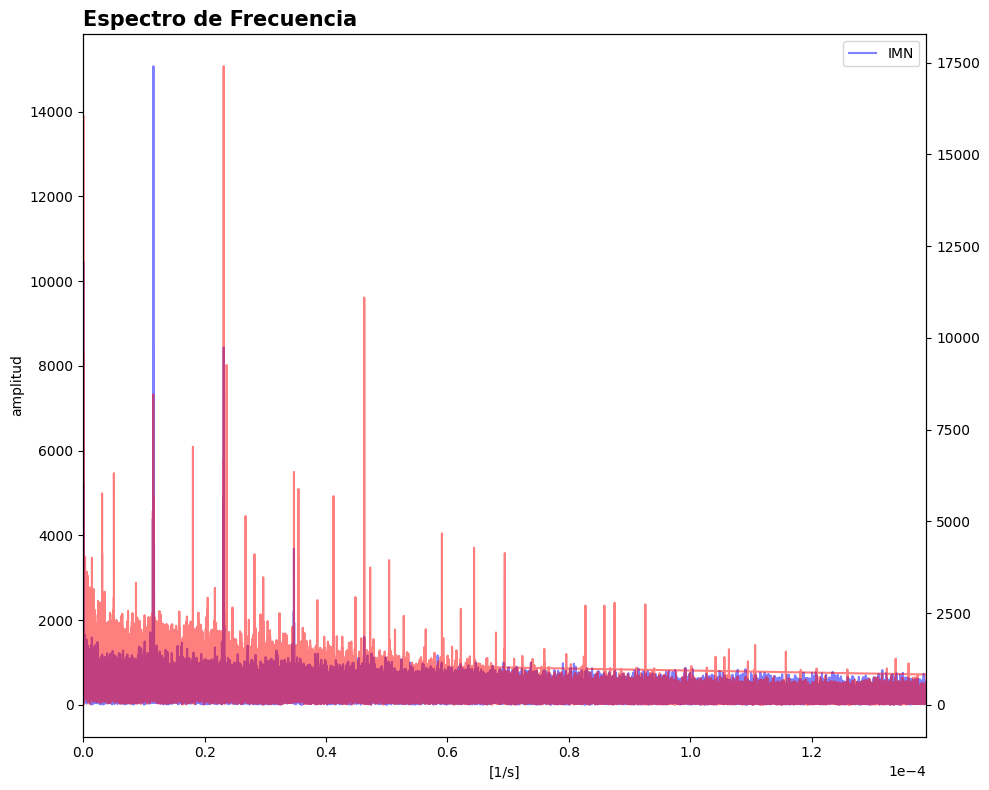

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(TF_1['XFT'], np.abs(TF_1['FT']),color= 'blue', alpha=0.5, label='IMN')
ax.set_ylabel('amplitud')
ax.set_xlabel('[1/s]')
ax.set_xlim(0, np.max(TF_1['XFT']))
ax.set_title('Espectro de Frecuencia', fontweight='bold', fontsize=15, loc='left')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.legend()

# To have two 'y' axes
twin_axes = ax.twinx()
 
twin_axes.plot(TF_2['XFT'], np.abs(TF_2['FT']),color= 'red', alpha=0.5, label='GPM')
    
fig.tight_layout()
plt.show()